In [1]:
import numpy as np
import pandas as pd
from matplotlib import cm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
df = pd.read_csv('data.csv')
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [2]:
df.isna().sum()#проверка наличия NaN

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [3]:
df['Fuel_Type'].unique()#с этой строчки идёт замена строковых значений на int

<ArrowStringArray>
['Diesel', 'Petrol', 'CNG']
Length: 3, dtype: str

In [4]:
size_map = {'Diesel' : 1, 'Petrol' : 2, 'CNG' : 3}
df['nFuel_Type'] = df['Fuel_Type'].map(size_map)
df = df.drop(columns=['Fuel_Type'])

In [5]:
print(df['Color'].unique())
size_map = {'Blue' : 1, 'Silver' : 2, 'Black' : 3, 'White' : 4, 'Grey' : 5, 'Red' : 6, 'Green' : 7, 'Yellow' : 8, 'Violet' : 9, 'Beige' : 10}
df['nColor'] = df['Color'].map(size_map)
df = df.drop(columns=['Color'])
df = df.drop(columns = ['Id'])

<ArrowStringArray>
[  'Blue', 'Silver',  'Black',  'White',   'Grey',    'Red',  'Green',
 'Yellow', 'Violet',  'Beige']
Length: 10, dtype: str


Столбцы формата str заменены на int, чтобы модель работала с одинаковым форматом данных и для удобства визуализации

([<matplotlib.axis.YTick at 0x1c9e7d012b0>,
 [Text(0, 0, 'Price'),
  Text(0, 1, 'Age_08_04'),
  Text(0, 2, 'Mfg_Month'),
  Text(0, 3, 'Mfg_Year'),
  Text(0, 4, 'KM'),
  Text(0, 5, 'HP'),
  Text(0, 6, 'Met_Color'),
  Text(0, 7, 'Automatic'),
  Text(0, 8, 'CC'),
  Text(0, 9, 'Doors'),
  Text(0, 10, 'Cylinders'),
  Text(0, 11, 'Gears'),
  Text(0, 12, 'Quarterly_Tax'),
  Text(0, 13, 'Weight'),
  Text(0, 14, 'Mfr_Guarantee'),
  Text(0, 15, 'BOVAG_Guarantee'),
  Text(0, 16, 'Guarantee_Period'),
  Text(0, 17, 'ABS'),
  Text(0, 18, 'Airbag_1'),
  Text(0, 19, 'Airbag_2'),
  Text(0, 20, 'Airco'),
  Text(0, 21, 'Automatic_airco'),
  Text(0, 22, 'Boardcomputer'),
  Text(0, 23, 'CD_Player'),
  Text(0, 24, 'Central_Lock'),
  Text(0, 25, 'Powered_Windows'),
  Text(0, 26, 'Power_Steering'),
  Text(0, 27, 'Radio'),
  Text(0, 28, 'Mistlamps'),
  Text(0, 29, 'Sport_Model'),
  Text(0, 30, 'Backseat_Divider'),
  Text(0, 31, 'Metallic_Rim'),
  Text(0, 32, 'Radio_cassette'),
  Text(0, 33, 'Parking_Assistant'

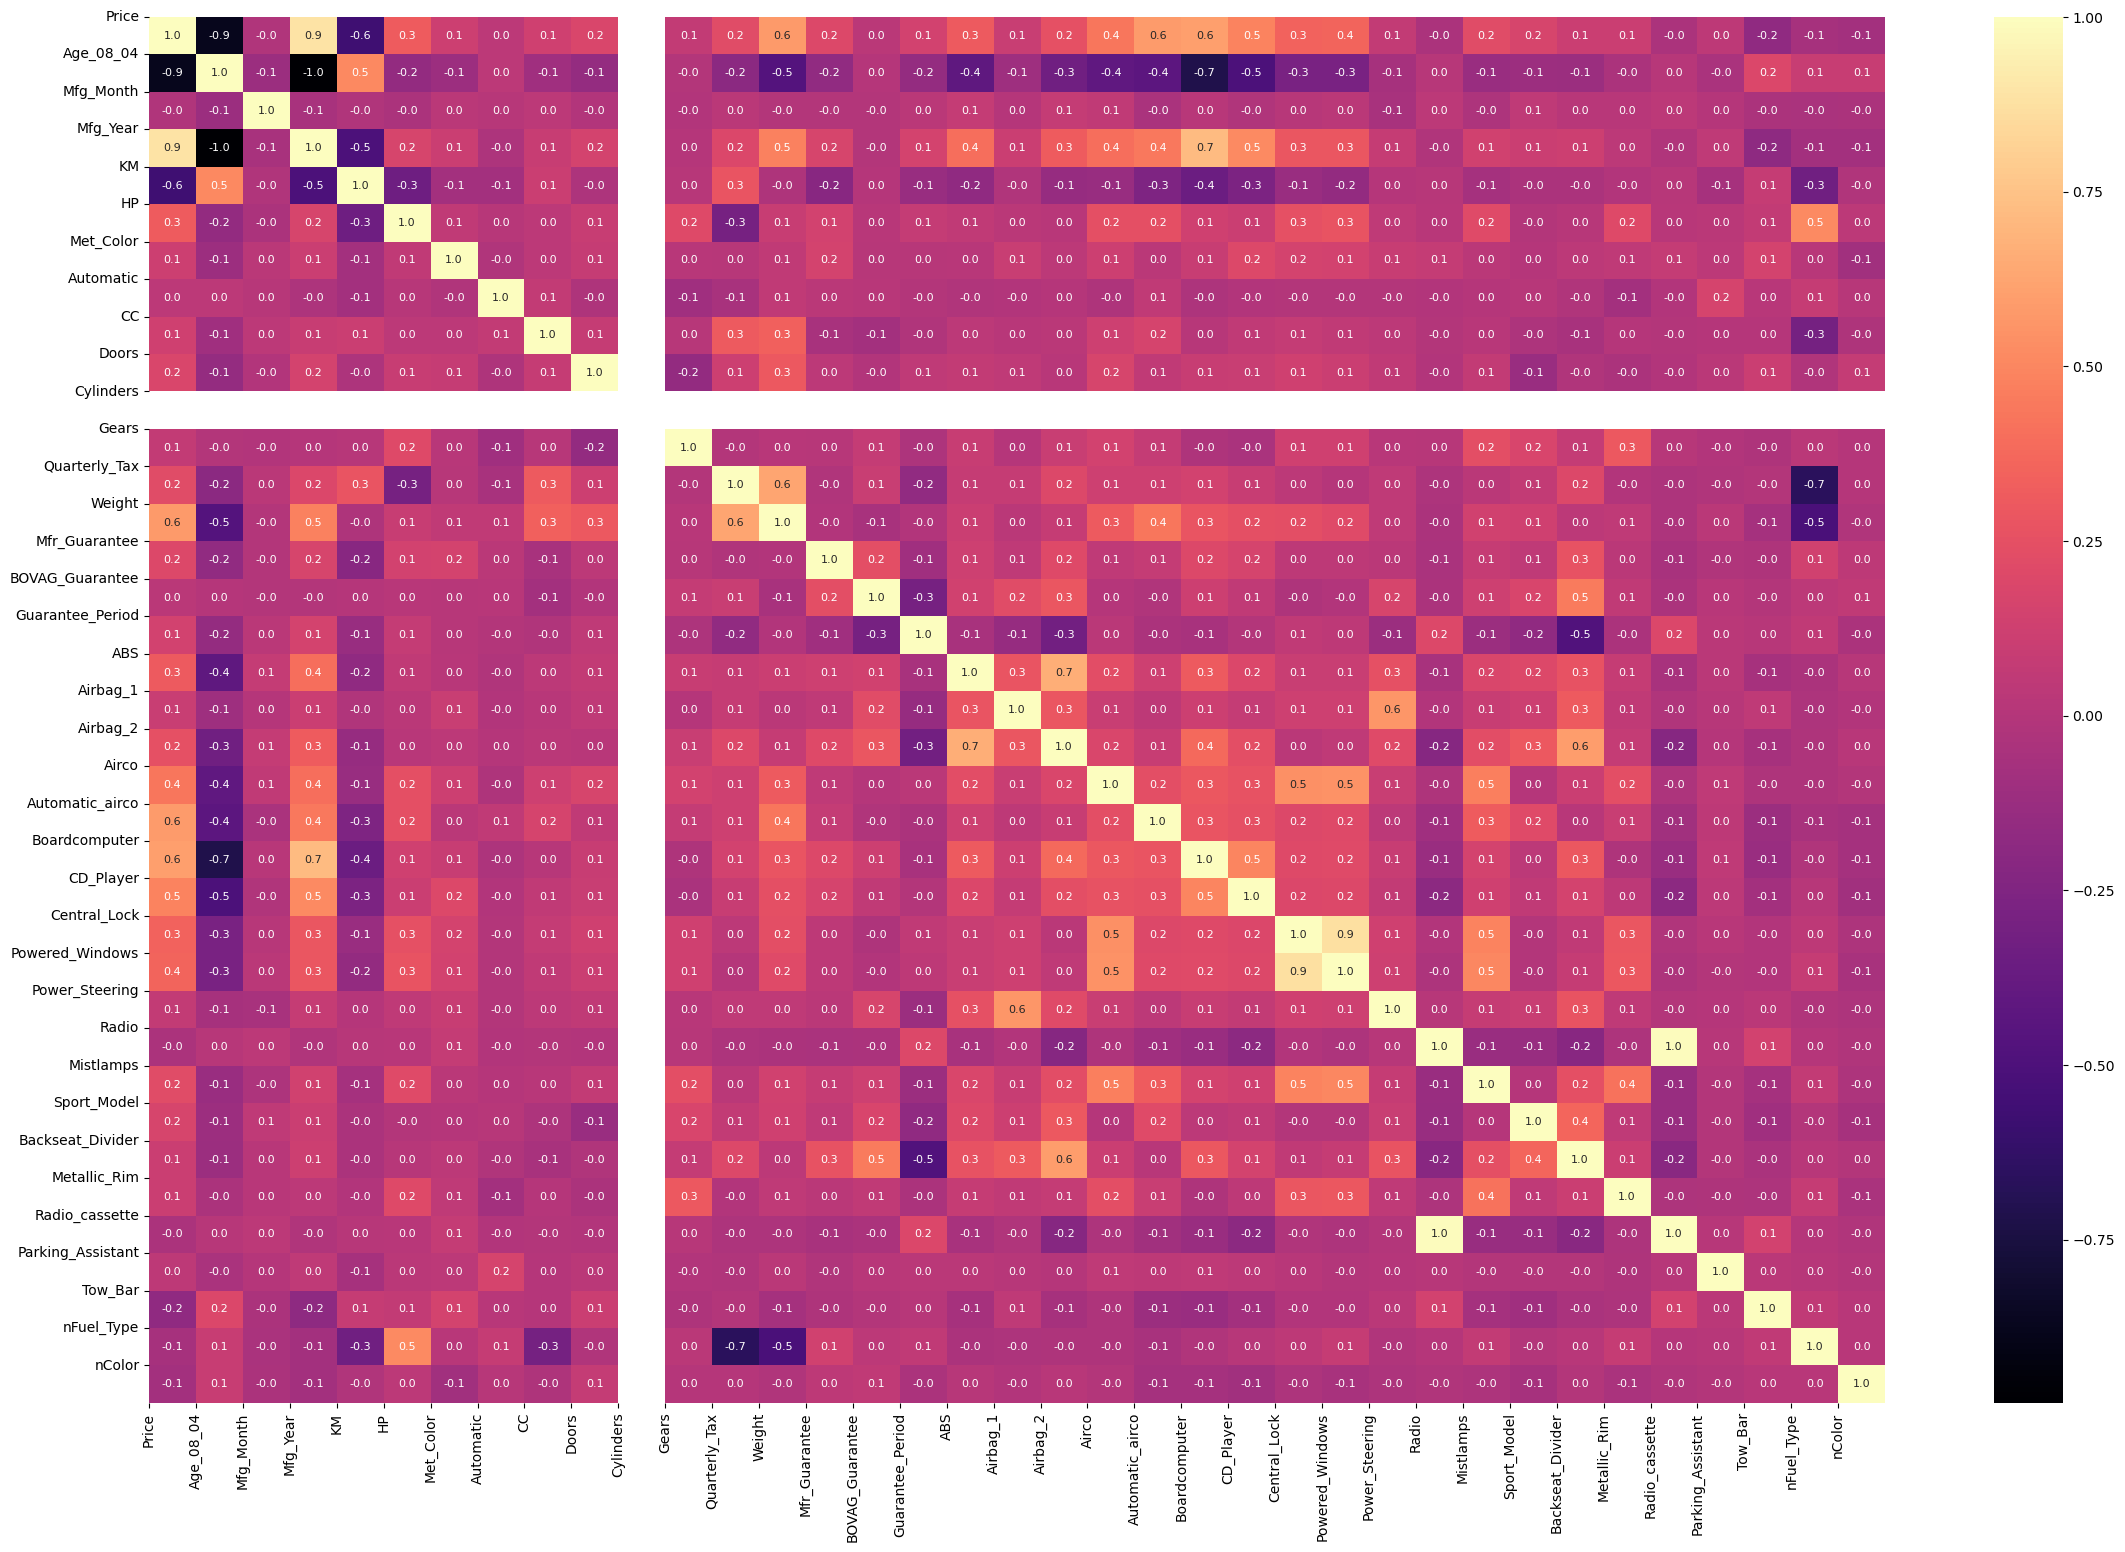

In [6]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(28, 18))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".1f", annot_kws = {'fontsize': 8})
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)


In [7]:
df['KM'].describe() 

count      1436.000000
mean      68533.259749
std       37506.448872
min           1.000000
25%       43000.000000
50%       63389.500000
75%       87020.750000
max      243000.000000
Name: KM, dtype: float64

In [8]:
df['Price'].describe()

count     1436.000000
mean     10730.824513
std       3626.964585
min       4350.000000
25%       8450.000000
50%       9900.000000
75%      11950.000000
max      32500.000000
Name: Price, dtype: float64

In [9]:
df = df[df['Price']<=30000]
df = df[df['Price']>=5000]
x = df.loc[:,['Mfg_Year', 'KM']]
y = df['Price']


In [10]:
df = df.drop(columns=['Model'])
df.tail()

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,...,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,nFuel_Type,nColor
1431,7500,69,12,1998,20544,86,1,0,1300,3,...,0,1,1,1,0,0,0,0,2,1
1432,10845,72,9,1998,19000,86,0,0,1300,3,...,0,0,1,1,0,0,0,0,2,5
1433,8500,71,10,1998,17016,86,0,0,1300,3,...,0,0,0,1,0,0,0,0,2,1
1434,7250,70,11,1998,16916,86,1,0,1300,3,...,0,0,0,1,0,0,0,0,2,5
1435,6950,76,5,1998,1,110,0,0,1600,5,...,0,0,0,0,0,0,0,0,2,7


In [11]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)
print(X_train.info())

<class 'pandas.DataFrame'>
Index: 1000 entries, 579 to 1133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Mfg_Year  1000 non-null   int64
 1   KM        1000 non-null   int64
dtypes: int64(2)
memory usage: 23.4 KB
None


In [12]:
linear_steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
]
params = {
    'poly__degree' : [1,2,3,4,5,6,7,8,9,10]
}

regressor_linear = Pipeline(linear_steps)
regressor_linear.fit(X_train, y_train)
gscv = GridSearchCV(regressor_linear, params, cv = 5)
gscv.fit(X_train, y_train)
linreg = gscv.best_estimator_
pr = linreg.predict(X_test)
r2 = r2_score(y_test, pr)
print(r2)

0.8405621730903474


In [23]:
df['Mfg_Year'].describe()

count    1429.000000
mean     1999.615115
std         1.529887
min      1998.000000
25%      1998.000000
50%      1999.000000
75%      2001.000000
max      2004.000000
Name: Mfg_Year, dtype: float64

## Визуализация
По оси X - год выпуска машины 

По оси Y - пробег(KM)

Чем цвет точки ближе к фиолетовому, тем предсказанная цена меньше

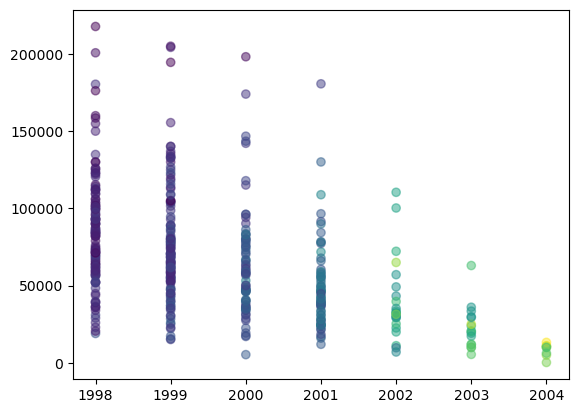

In [13]:
x_test_plt, y_test_plt = X_test.iloc[:,0], X_test.iloc[:,1]
z_test_plt = y_test
plt.scatter(x_test_plt, y_test_plt, c = z_test_plt, alpha = .5)
plt.show()

In [28]:
print(X_test['Mfg_Year'])

126     2003
1196    1998
468     2000
356     2001
1015    1999
        ... 
573     2000
595     2000
1041    1999
555     2000
396     2000
Name: Mfg_Year, Length: 429, dtype: int64


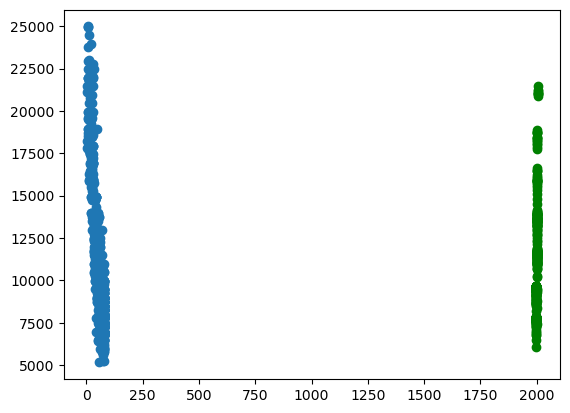

In [29]:
plt.scatter(df['Age_08_04'], y)
plt.scatter(X_test['Age_08_04'], pr, c = 'green')
plt.show()